# Restaurant Segmentation using K-Means Clustering

This notebook applies K-Means clustering to segment restaurants based on star rating and review count.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
# Load processed dataset
df = pd.read_csv("processed_yelp_restaurants.csv")

df.head()

,business_id,name,city,state,stars,review_count,categories,WiFi_Status
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,Philadelphia,PA,4.0,80,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...",u'free'
1,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,Ashland City,TN,2.0,6,"Burgers, Fast Food, Sandwiches, Food, Ice Crea...",u'no'
2,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,Nashville,TN,1.5,10,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,...",u'no'
3,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,Tampa Bay,FL,4.0,10,"Vietnamese, Food, Restaurants, Food Trucks",No Info
4,il_Ro8jwPlHresjw9EGmBg,Denny's,Indianapolis,IN,2.5,28,"American (Traditional), Restaurants, Diners, B...",u'no'


In [3]:
# Select features for clustering
cluster_data = df[['stars', 'review_count']]

cluster_data.head()

,stars,review_count
0,4.0,80
1,2.0,6
2,1.5,10
3,4.0,10
4,2.5,28


In [5]:
## Data Standardization

# Standardising features because stars and review_count have different scales
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

scaled_data[:5]

array([[ 0.55191111, -0.10944756],
       [-1.76652971, -0.4449153 ],
       [-2.34613992, -0.42678191],
       [ 0.55191111, -0.42678191],
       [-1.18691951, -0.34518165]])

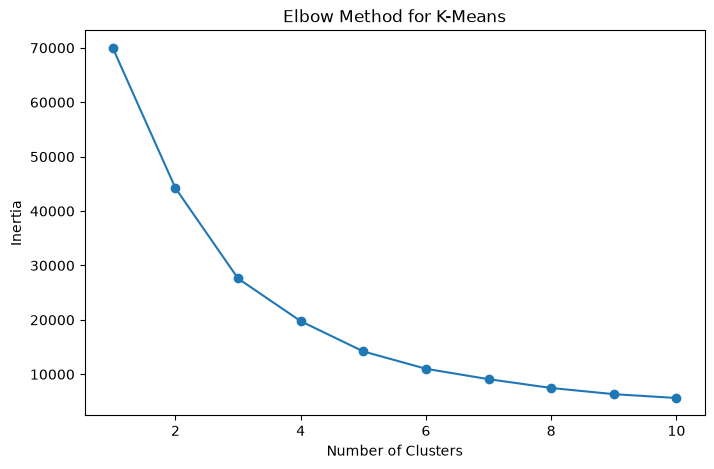

In [6]:
## Elbow Method

#The elbow method is used to support the choice of the number of clusters.
# Calculate inertia for different values of k
inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(scaled_data)
    inertia.append(model.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))

plt.plot(range(1, 11), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.show()

In [7]:
## K-Means Clustering
# Applying K-Means with 3 clusters
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(scaled_data)

df[['stars', 'review_count', 'cluster']].head()

,stars,review_count,cluster
0,4.0,80,2
1,2.0,6,0
2,1.5,10,0
3,4.0,10,2
4,2.5,28,0


## Cluster Distribution

In [8]:
# Count number of restaurants in each cluster
df['cluster'].value_counts()

cluster
2    23310
0    11224
1      453
Name: count, dtype: int64

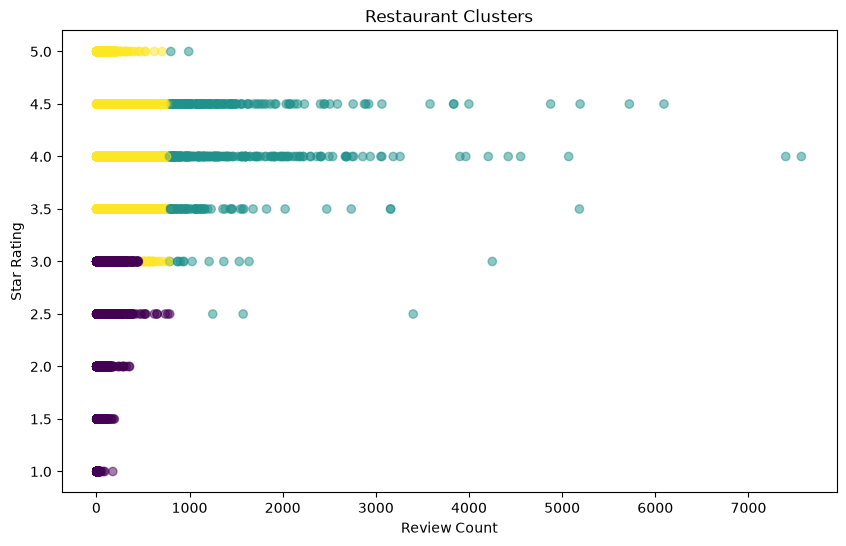

In [9]:
## Cluster Visualization
# Visualize clusters using review count and star rating
plt.figure(figsize=(10,6))

plt.scatter(
    df['review_count'],
    df['stars'],
    c=df['cluster'],
    alpha=0.5
)

plt.xlabel('Review Count')
plt.ylabel('Star Rating')
plt.title('Restaurant Clusters')

plt.show()

## Cleaner Cluster Visualization

The full scatterplot is affected by restaurants with extremely large review counts, so a filtered version is also shown.

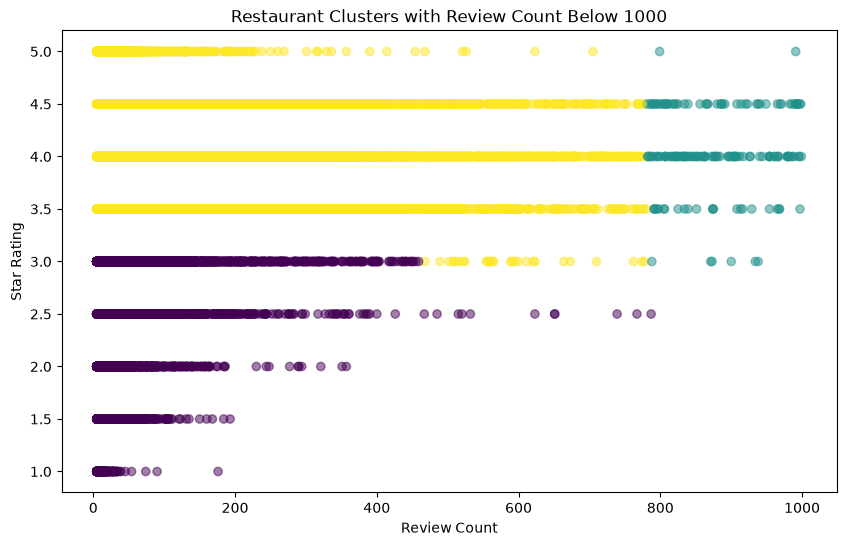

In [10]:
# Filtering extreme review count values for clearer visualization
sample_df = df[df['review_count'] < 1000]

plt.figure(figsize=(10,6))

plt.scatter(
    sample_df['review_count'],
    sample_df['stars'],
    c=sample_df['cluster'],
    alpha=0.5
)

plt.xlabel('Review Count')
plt.ylabel('Star Rating')
plt.title('Restaurant Clusters with Review Count Below 1000')

plt.show()

## Cluster Interpretation

In [ ]:
# Calculating average stars and review count per cluster
cluster_summary = df.groupby('cluster')[['stars', 'review_count']].mean()

cluster_summary

,stars,review_count
cluster,,
0,2.473940,43.222470
1,4.079470,1456.408389
2,4.018662,107.196954


In [13]:
# Evaluating clustering quality using silhouette score
silhouette = silhouette_score(
    scaled_data,
    df['cluster']
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.5202046375311101


## Restaurant Performance Categories

Restaurants are also classified into simple business performance categories using star rating and review count.

In [14]:
# Define performance classification function
def classify_restaurant(row):

    if row['stars'] >= 4.0 and row['review_count'] >= 200:
        return 'Top Performer'

    elif row['stars'] >= 4.0:
        return 'High Rated'

    elif row['review_count'] >= 200:
        return 'Popular'

    else:
        return 'Average'


# Apply performance category classification
df['performance_category'] = df.apply(
    classify_restaurant,
    axis=1
)

df['performance_category'].value_counts()

performance_category
Average          17239
High Rated       13108
Top Performer     3283
Popular           1357
Name: count, dtype: int64

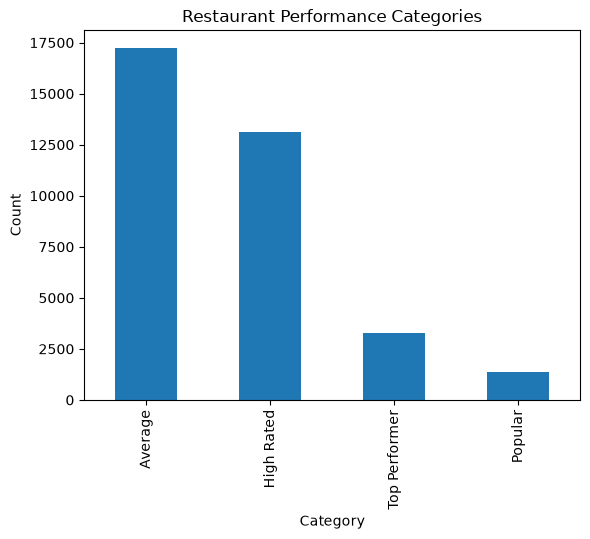

In [15]:
# Visualize restaurant performance categories
df['performance_category'].value_counts().plot(
    kind='bar'
)

plt.title('Restaurant Performance Categories')
plt.xlabel('Category')
plt.ylabel('Count')

plt.show()

In [16]:
# Save dataset with cluster labels and performance categories
df.to_csv("segmented_yelp_restaurants.csv", index=False)

print("Segmented dataset saved successfully.")

Segmented dataset saved successfully.
